# Análise de Coerência F0–Energia — Bona fide vs Spoof (TTS)

Mede-se o **acoplamento espectral entre o contorno de F0 e a envoltória de energia**
de cada *utterance*, comparando fala real (*bona fide*) e fala sintética de cinco
modelos TTS (F5-TTS, XTTS, ToucanTTS, Fish-Speech, YourTTS) no dataset BRSpeech-DF.

**Hipótese.** O acoplamento F0–energia é mais forte (coerência maior) na fala
genuína, porque ambos derivam de um *drive* aerodinâmico-laríngeo comum (pressão
subglótica): elevar F0 exige maior tensão das pregas vocais **e** maior pressão
subglótica, que por sua vez eleva o nível de pressão sonora — logo altura e
intensidade covariam na fonação humana. Modelos TTS, que geram periodicidade
(F0) e amplitude (energia) por caminhos em grande parte independentes, tenderiam
a quebrar esse vínculo de produção.

**Estrutura**
1. Setup, funções auxiliares e carregamento (reaproveitados da análise acústica)
2. Coerência F0–energia: extração, escalares e curva média $C_{xy}(f)$
3. (Opcional) Coerência F0–ZCR
4. Síntese
5. Ressalvas metodológicas


# 1. Setup


In [1]:
%%capture
pip install pandas fastparquet matplotlib seaborn scipy librosa tqdm


In [2]:
# Imports (todos centralizados aqui)
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# usados apenas na extração de features de pausa (seção 6)
import librosa
from tqdm.auto import tqdm

# coerência (estimador de Welch interno)
from scipy import signal


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Configuração: caminhos, ordem e nomes dos grupos
PATH_DF     = "./feature_extraction/metrics_brpseechdf.parquet"
PATH_REAPER = "./feature_extraction/metrics_brpseechdf_reaper.parquet"

MODELOS = ["f5tts", "xtts", "toucantts", "fish-speech", "yourtts"]
ORDEM   = ["real"] + MODELOS          # "real" primeiro, depois os modelos

NOMES = {
    "real": "Bona fide", "f5tts": "F5-TTS", "xtts": "XTTS",
    "toucantts": "ToucanTTS", "fish-speech": "Fish-Speech", "yourtts": "YourTTS",
}

# --- parâmetros da coerência -------------------------------------------------
# nperseg controla o trade-off: resolução em frequência  x  nº de segmentos de
# Welch (médias). Coerência de 1 único segmento é identicamente 1 (artefato),
# por isso exigimos vários segmentos por utterance (MIN_SEG).
#   nperseg=256 -> res 0,78 Hz, 7 bins < 5 Hz, exige utterances mais longas
#   nperseg=128 -> res 1,56 Hz, 4 bins < 5 Hz, menos descartes   (padrão)
NPERSEG         = 128
NOVERLAP        = NPERSEG // 2
BANDA_PROSODICA = 5.0      # Hz — banda de modulação prosódica
MIN_SEG         = 3        # nº mínimo de segmentos p/ aceitar a estimativa


### 1.2. Funções auxiliares (tabelas e gráficos)

Reaproveitadas da análise acústica — operam sobre colunas de `data`, então valem
para os escalares de coerência sem alteração.


In [4]:
# --- parsing e estatísticas ---------------------------------------------------

def to_array(s):
    """Converte série do REAPER (string ou lista) em np.array de floats."""
    if isinstance(s, str):
        s = ast.literal_eval(s)
    return np.asarray(s, dtype=float)

# alias para trechos que ainda chamam parse_list_col
parse_list_col = to_array


def _fmt(g, c):
    """'mediana (média ± desvio)' de uma coluna."""
    return f"{g[c].median():.4g} ({g[c].mean():.4g} ± {g[c].std():.4g})"


def resumo_real_falso(params):
    """Tabela mediana (média ± dp) por métrica, real vs falso."""
    real  = data[data.grupo == "real"]
    falso = data[data.grupo == "falso"]
    return pd.DataFrame({
        "real":  {k: _fmt(real,  v) for k, v in params.items()},
        "falso": {k: _fmt(falso, v) for k, v in params.items()},
    })


def kl_divergence(p_samples, q_samples, n_points=1000):
    """KL(P || Q) via KDE — P=real, Q=modelo."""
    x = np.linspace(min(p_samples.min(), q_samples.min()),
                    max(p_samples.max(), q_samples.max()), n_points)
    p = np.clip(gaussian_kde(p_samples)(x), 1e-10, None)
    q = np.clip(gaussian_kde(q_samples)(x), 1e-10, None)
    p /= p.sum(); q /= q.sum()
    return np.sum(p * np.log(p / q))


def tabela_kl(params):
    """KL(real || modelo) para cada modelo e métrica."""
    real = data[data["modelo_grupo"] == "real"]
    rows = []
    for modelo in MODELOS:
        falso = data[data["modelo_grupo"] == modelo]
        row = {"Model": modelo}
        for titulo, col in params.items():
            p = real[col].dropna().values
            q = falso[col].dropna().values
            row[titulo] = round(kl_divergence(p, q), 4) if len(p) > 1 and len(q) > 1 else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("Model")


def medianas_por_modelo(params):
    """Mediana de cada métrica por grupo (real + modelos), na ORDEM padrão."""
    med = (data[data["modelo_grupo"].isin(ORDEM)]
           .groupby("modelo_grupo")[list(params.values())]
           .median()
           .reindex(ORDEM))
    med.columns = list(params.keys())
    return med

In [5]:
# --- gráficos -----------------------------------------------------------------

def violin_real_falso(params, suptitle=None, ylabel=""):
    fig, axs = plt.subplots(1, len(params), figsize=(6 * len(params), 4), squeeze=False)
    for ax, (titulo, col) in zip(axs[0], params.items()):
        sns.violinplot(data=data, x="grupo", y=col, inner="box",
                       hue="grupo", legend=False, ax=ax)
        ax.set_title(titulo); ax.set_xlabel(""); ax.set_ylabel(ylabel)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


def barras_real_falso(params, suptitle=None):
    fig, axs = plt.subplots(1, len(params), figsize=(4.5 * len(params), 4), squeeze=False)
    for ax, (titulo, col) in zip(axs[0], params.items()):
        sns.barplot(data=data, x="grupo", y=col, estimator="median", errorbar=("pi", 50),
                    hue="grupo", legend=False, ax=ax)
        ax.set_title(titulo, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("Mediana")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


def hist_real_falso(params, suptitle=None):
    fig, axs = plt.subplots(1, len(params), figsize=(4.5 * len(params), 4), squeeze=False)
    for ax, (titulo, col) in zip(axs[0], params.items()):
        sns.histplot(data=data, x=col, hue="grupo", bins=40, element="step",
                     stat="density", common_norm=False, alpha=0.4, ax=ax)
        ax.set_title(titulo, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("Densidade")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


def hist_por_modelo(params, suptitle=None):
    """Grade len(MODELOS) x len(params): real vs cada modelo."""
    real = data[data["modelo_grupo"] == "real"]
    fig, axs = plt.subplots(len(MODELOS), len(params),
                            figsize=(5 * len(params), 4 * len(MODELOS)), squeeze=False)
    for r, modelo in enumerate(MODELOS):
        falso = data[data["modelo_grupo"] == modelo]
        for c, (titulo, col) in enumerate(params.items()):
            ax = axs[r, c]
            ax.hist(real[col].dropna(),  bins=40, alpha=0.5, density=True,
                    label="Real",  color="steelblue")
            ax.hist(falso[col].dropna(), bins=40, alpha=0.5, density=True,
                    label=modelo, color="salmon")
            ax.set_title(f"{titulo} — real vs {modelo}", fontsize=9)
            ax.set_xlabel(""); ax.set_ylabel("Densidade"); ax.legend(fontsize=8)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()


def violin_por_modelo(params, suptitle=None):
    """Um violino por métrica (linhas), grupos no eixo x."""
    fig, axs = plt.subplots(len(params), 1,
                            figsize=(max(8, len(ORDEM) * 1.2), 4 * len(params)), squeeze=False)
    for ax, (titulo, col) in zip(axs[:, 0], params.items()):
        sns.violinplot(data=data, x="modelo_grupo", y=col, order=ORDEM, inner="box",
                       hue="modelo_grupo",
                       palette=["steelblue"] + ["salmon"] * len(MODELOS),
                       legend=False, ax=ax)
        ax.set_title(titulo); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()


def barras_mediana(params, suptitle=None, ylabel="Mediana"):
    """Um subplot de barras por métrica, com a mediana de cada grupo."""
    med = medianas_por_modelo(params)
    fig, axs = plt.subplots(1, len(params), figsize=(4.5 * len(params), 4), squeeze=False)
    for ax, (metrica, color) in zip(axs[0], zip(params.keys(), plt.cm.tab10.colors)):
        ax.bar(np.arange(len(ORDEM)), med[metrica], color=color,
               edgecolor="white", linewidth=0.5, width=0.6)
        ax.set_xticks(np.arange(len(ORDEM)))
        ax.set_xticklabels(ORDEM, rotation=30, ha="right", fontsize=9)
        ax.set_title(metrica, fontsize=11); ax.set_ylabel(ylabel)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

### 1.3. Carregamento e preparação dos dados


In [6]:
# Carrega métricas escalares (df) + séries temporais do REAPER (rea) e junta por 'file'
df  = pd.read_parquet(PATH_DF)
rea = pd.read_parquet(PATH_REAPER)

for col in ["times_reaper", "f0_reaper", "corr"]:
    rea[col] = rea[col].apply(to_array)

data = df.merge(rea[["file", "times_reaper", "f0_reaper", "corr"]],
                on="file", how="inner")

print("escalares:", df.shape, "| séries:", rea.shape, "| juntos:", data.shape)
data.head(2)

escalares: (7891, 17) | séries: (7891, 7) | juntos: (7891, 20)


,file,path,model,patient,f0_mean_hz,f0_std_hz,f0_median_hz,jitter_local_pct,jitter_rap_pct,jitter_ppq5_pct,jitter_ddp_pct,shimmer_local_pct,shimmer_dB,shimmer_apq3_pct,shimmer_apq5_pct,shimmer_dda_pct,hnr_mean_dB,times_reaper,f0_reaper,corr
0,11247_10229_000006-0002.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,224.070221,42.466167,224.299072,1.465307,0.513634,0.617712,1.540903,5.273076,0.630496,1.286512,2.331734,3.859535,18.005527,"[0.0, 0.004999999888241291, 0.0099999997764825...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[0.0, 0.27889445424079895, 0.2583264410495758,..."
1,11247_10229_000031-0001.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,213.524521,35.721504,214.285721,1.484062,0.520242,0.722275,1.560727,5.217174,0.545237,1.253511,2.296803,3.760533,19.032114,"[0.0, 0.004999999888241291, 0.0099999997764825...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[0.33542969822883606, 0.33542969822883606, 0.5..."


In [7]:
# Colunas derivadas (criadas uma única vez)
data["is_bonafide"] = (data["patient"].str.lower() == "bonafide").astype(int)
data["grupo"]       = np.where(data["is_bonafide"] == 1, "real", "falso")
data["spoof_model"] = data["patient"]

# locutor = 1º token do nome do arquivo
data["speaker"] = data["file"].str.split("_").str[0]

# modelo_grupo: "real" se bonafide, senão o nome do modelo (speaker)
data["modelo_grupo"] = np.where(data["is_bonafide"] == 1, "real", data["speaker"])

print("Classes (patient):")
print(data["patient"].value_counts(), "\n")
print("Splits (model):", data["model"].unique())

# Tabela I do artigo: distribuição por classe
tab1 = (data["patient"].value_counts()
        .rename_axis("spoof_model").reset_index(name="n"))
tab1["%"] = (100 * tab1["n"] / tab1["n"].sum()).round(1)
tab1.loc[len(tab1)] = ["Total", tab1["n"].sum(), 100.0]
display(tab1)

Classes (patient):
patient
spoof       6575
bonafide    1316
Name: count, dtype: int64 

Splits (model): ['test']


,spoof_model,n,%
0,spoof,6575,83.3
1,bonafide,1316,16.7
2,Total,7891,100.0


# Visão geral do experimento

- **Objetivo:** quantificar o acoplamento F0–energia (coerência) em fala real vs
  sintética de 5 modelos TTS, no split `test` do BRSpeech-DF.
- **Base:** 7.891 áudios após o *merge* das métricas escalares com as séries
  temporais do REAPER (`times_reaper`, `f0_reaper`).
- **Desbalanceamento de classes:** ~6.575 *spoof* (83%) vs ~1.316 *bonafide* (17%).
  Não atrapalha a comparação descritiva de medianas, mas é crítico se os escalares
  alimentarem um classificador.
- **Sinais usados:** contorno de F0 (do REAPER, `f0_reaper`, com −1 nos trechos
  não-vozeados) e envoltória de energia (RMS por frame, calculada da forma de onda).
- **Tabela de qualidade do TTS (referência, para cruzamento):**

<center>

| Model | uTMOS ↑ | Spk. Sim. ↑ | SI-SDR (dB) ↑ | WER (%) ↓ |
|---|---|---|---|---|
| F5-TTS | 3,39 | 0,71 | 20,86 | 14,13 |
| XTTS | 3,37 | 0,71 | 25,97 | **5,50** |
| ToucanTTS | 3,20 | 0,60 | **26,50** | 19,18 |
| Fish-Speech | 3,11 | **0,76** | 22,33 | 11,43 |
| YourTTS | 2,58 | 0,41 | 16,92 | 14,21 |
| *Bona fide* | 3,44 | – | – | 9,11 |

</center>


# 2. Coerência F0–energia

Para dois sinais no tempo $x[n]$ e $y[n]$, a **coerência de magnitude quadrática** é

$$C_{xy}(f) = \frac{|S_{xy}(f)|^2}{S_{xx}(f)\,S_{yy}(f)}, \qquad C_{xy}(f) \in [0,1],$$

onde $S_{xx}, S_{yy}$ são as densidades espectrais de cada sinal e $S_{xy}$ o
espectro cruzado. $C_{xy}(f)=1$ indica acoplamento perfeito na frequência $f$;
$C_{xy}(f)=0$, independência. A estimativa sai de `scipy.signal.coherence`, que
internamente usa o estimador de **Welch** (segmentação + média).

**Receita por utterance (Etapa 2):**
1. Envoltória de energia (**RMS por frame**) da forma de onda, no mesmo *hop* do F0.
2. **Interpolação** dos trechos não-vozeados do F0 (marcados −1) para não contaminar
   a estimativa.
3. $C_{xy}(f)$ entre F0 e energia via `scipy.signal.coherence`, com a **taxa de
   frames** como taxa de amostragem.
4. **Escalar(es):** coerência média global e — sobretudo — a média na **banda de
   modulação prosódica** ($f < 5$ Hz), onde o acoplamento de produção se manifesta.

> **Cuidado (Welch):** a coerência de **um único segmento é identicamente 1**.
> É preciso garantir vários segmentos por utterance — daí `NPERSEG` pequeno em
> relação ao comprimento e o descarte de utterances curtas (`MIN_SEG`).


In [8]:
# --- coerência F0–energia (e F0–ZCR) -----------------------------------------

def _nan_coh():
    return {"coh_mean": np.nan, "coh_pros": np.nan, "coh_zcr_pros": np.nan,
            "coh_curve": None, "coh_zcr_curve": None, "coh_f": None}


def coerencia_utterance(row, nperseg=NPERSEG, noverlap=NOVERLAP,
                        fmax=BANDA_PROSODICA, min_seg=MIN_SEG):
    """Coerência (Welch) F0–energia de uma utterance (Eq. 4).

    1) RMS por frame no mesmo hop do F0; 2) interpola F0 não-vozeado (-1);
    3) signal.coherence(F0, energia), fs = taxa de frames; 4) escalares:
    média global e média na banda prosódica (< fmax). ZCR é opcional.
    """
    try:
        f0    = np.asarray(row["f0_reaper"],    dtype=float)
        times = np.asarray(row["times_reaper"], dtype=float)
        frame_dur = float(np.diff(times).mean()) if len(times) > 1 else 0.005
        fs = 1.0 / frame_dur                       # taxa de frames (~200 Hz)

        # 1) envoltórias de energia (RMS) e ZCR por frame, no hop do F0
        y, sr = librosa.load(row["path"], sr=None)
        hop = int(round(frame_dur * sr))
        win = max(hop, int(round(0.025 * sr)))     # janela ~25 ms
        rms = librosa.feature.rms(y=y, frame_length=win, hop_length=hop)[0]
        zcr = librosa.feature.zero_crossing_rate(y, frame_length=win,
                                                 hop_length=hop)[0]

        # 2) interpola trechos não-vozeados do F0 (-1)
        voiced = f0 > 0
        if voiced.sum() < 2:
            return _nan_coh()
        idx = np.arange(len(f0))
        f0i = np.interp(idx, idx[voiced], f0[voiced])

        # alinha comprimentos (F0 x envoltórias)
        n = min(len(f0i), len(rms), len(zcr))
        f0i, rms, zcr = f0i[:n], rms[:n], zcr[:n]

        # exige >= min_seg segmentos (1 segmento -> coerência ≡ 1, inútil)
        if n < nperseg + (min_seg - 1) * (nperseg - noverlap):
            return _nan_coh()

        # 3) coerência F0–energia  e  F0–ZCR (opcional)
        f,  Cxy  = signal.coherence(f0i, rms, fs=fs,
                                    nperseg=nperseg, noverlap=noverlap)
        _,  Czcr = signal.coherence(f0i, zcr, fs=fs,
                                    nperseg=nperseg, noverlap=noverlap)

        # 4) escalares
        band = f < fmax
        return {
            "coh_mean":      float(np.mean(Cxy)),
            "coh_pros":      float(np.mean(Cxy[band]))  if band.any() else np.nan,
            "coh_zcr_pros":  float(np.mean(Czcr[band])) if band.any() else np.nan,
            "coh_curve":     Cxy,
            "coh_zcr_curve": Czcr,
            "coh_f":         f,
        }
    except Exception:
        return _nan_coh()


# --- curva média de coerência ------------------------------------------------

def _matriz_curvas(mask, col="coh_curve"):
    """Empilha as curvas Cxy(f) válidas (mesma grade FREQ) de um subconjunto."""
    sub = data.loc[mask & data[col].notnull(), col].values
    return np.vstack(sub) if len(sub) else np.empty((0, len(FREQ)))


def curva_media(grupos, suptitle=None, banda=BANDA_PROSODICA):
    """grupos: dict nome -> matriz (n_utt x n_freq). Plota média + faixa IQR."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for nome, M in grupos.items():
        if M.size == 0:
            continue
        m      = np.nanmean(M, axis=0)
        q1, q3 = np.nanpercentile(M, [25, 75], axis=0)
        line,  = ax.plot(FREQ, m, label=f"{nome} (n={M.shape[0]})")
        ax.fill_between(FREQ, q1, q3, alpha=0.15, color=line.get_color())
    ax.axvline(banda, ls="--", color="gray", lw=1)
    ax.set_xlabel("Frequência (Hz)"); ax.set_ylabel(r"Coerência $C_{xy}(f)$")
    ax.set_ylim(0, 1); ax.legend(fontsize=9)
    if suptitle:
        ax.set_title(suptitle, fontsize=12)
    plt.tight_layout(); plt.show()


In [9]:
# Extração (carrega áudio de row["path"]: rode no ambiente com os .flac)
rows = [coerencia_utterance(r)
        for _, r in tqdm(data.iterrows(), total=len(data),
                         desc="Coerência F0–energia")]
res = pd.DataFrame(rows, index=data.index)

# grade de frequência (constante: fs e nperseg fixos)
FREQ = next((f for f in res["coh_f"] if f is not None), None)

data = data.drop(columns=["coh_mean", "coh_pros", "coh_zcr_pros",
                          "coh_curve", "coh_zcr_curve"], errors="ignore")
data = pd.concat([data, res.drop(columns=["coh_f"])], axis=1)

n_ok = int(data["coh_pros"].notnull().sum())
print(f"Estimativas válidas: {n_ok}/{len(data)} "
      f"({100*n_ok/len(data):.1f}%) | descartadas (curtas): {len(data)-n_ok}")
if FREQ is not None:
    print(f"Grade: {len(FREQ)} bins, 0–{FREQ[-1]:.1f} Hz, "
          f"res {FREQ[1]-FREQ[0]:.2f} Hz, bins < {BANDA_PROSODICA:.0f} Hz: "
          f"{int((FREQ < BANDA_PROSODICA).sum())}")


Coerência F0–energia: 100%|██████████| 7891/7891 [02:37<00:00, 50.13it/s] 

Estimativas válidas: 7661/7891 (97.1%) | descartadas (curtas): 230
Grade: 65 bins, 0–100.0 Hz, res 1.56 Hz, bins < 5 Hz: 4


### 2.1. Escalares — Real vs Falso

`coh_mean` é a média sobre **todas** as frequências; `coh_pros` é a média na
banda prosódica (< 5 Hz). Em validação com sinais sintéticos, `coh_mean` quase
não separa acoplado de independente (o ruído de alta frequência domina a média),
enquanto `coh_pros` separa fortemente — **o escalar discriminativo é o `coh_pros`**.


In [10]:
PARAMS_COH = {
    "Coerência média": "coh_mean",
    "Coerência prosódica (<5 Hz)": "coh_pros",
}
resumo_real_falso(PARAMS_COH)


,real,falso
Coerência média,0.09771 (0.1244 ± 0.08364),0.091 (0.1158 ± 0.08076)
Coerência prosódica (<5 Hz),0.1191 (0.15 ± 0.1148),0.136 (0.1654 ± 0.1183)


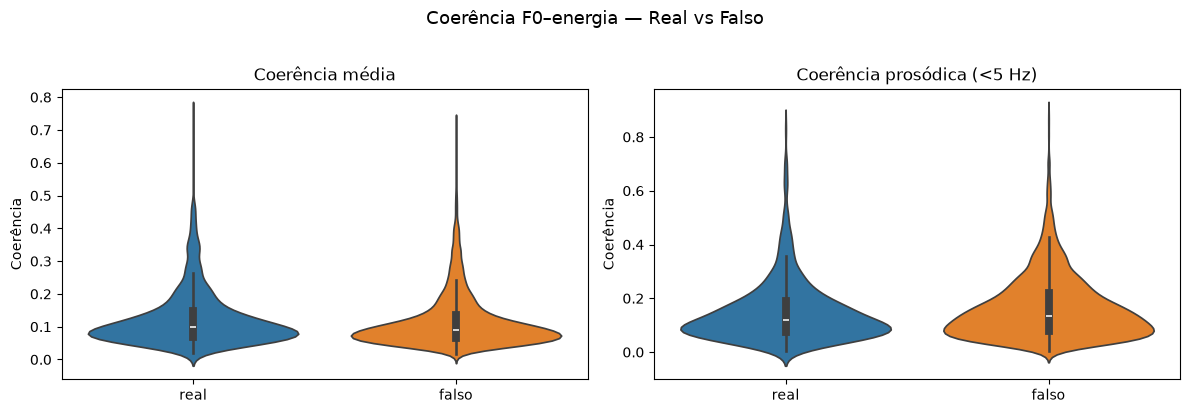

In [11]:
violin_real_falso(PARAMS_COH,
                  suptitle="Coerência F0–energia — Real vs Falso",
                  ylabel="Coerência")


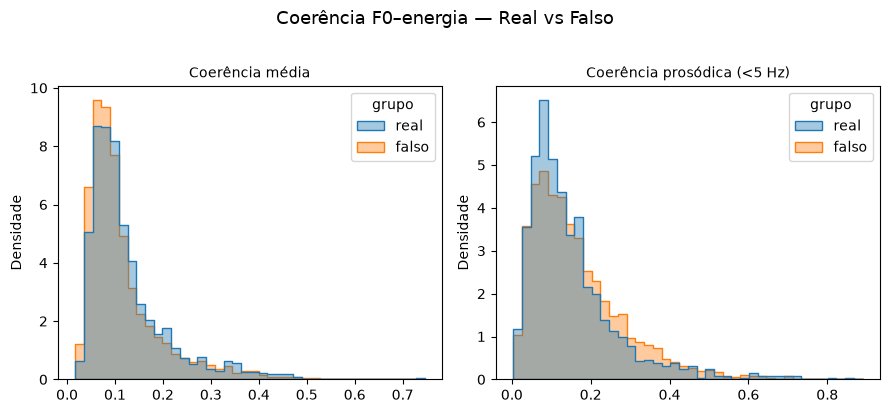

In [12]:
hist_real_falso(PARAMS_COH, suptitle="Coerência F0–energia — Real vs Falso")


### 2.2. Curva média $C_{xy}(f)$ — Real vs Falso

A assinatura central: a curva média de coerência por grupo. A hipótese prevê
$C_{xy}(f)$ **mais alta na fala real na faixa < 5 Hz** (linha tracejada).


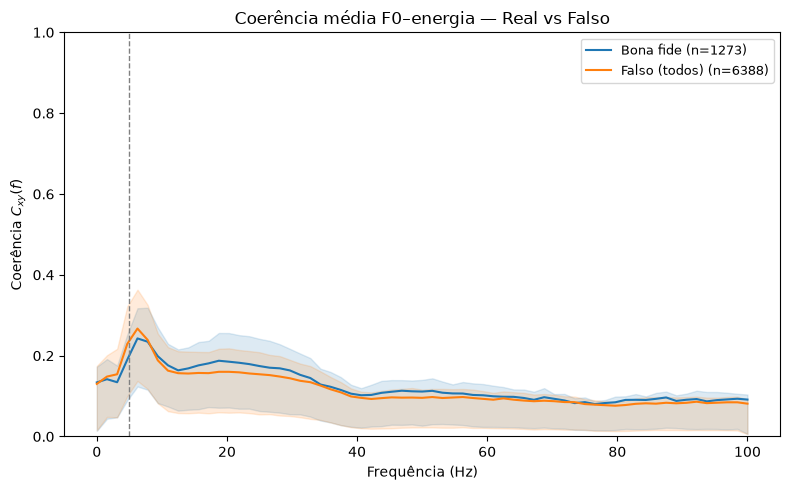

In [13]:
grupos_rf = {
    NOMES["real"]:  _matriz_curvas(data["grupo"] == "real"),
    "Falso (todos)": _matriz_curvas(data["grupo"] == "falso"),
}
curva_media(grupos_rf, suptitle="Coerência média F0–energia — Real vs Falso")


### Por modelo


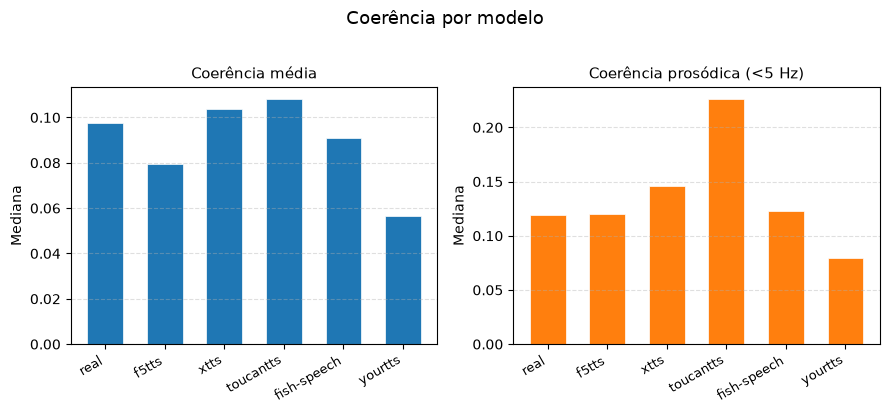

In [14]:
barras_mediana(PARAMS_COH, suptitle="Coerência por modelo", ylabel="Mediana")


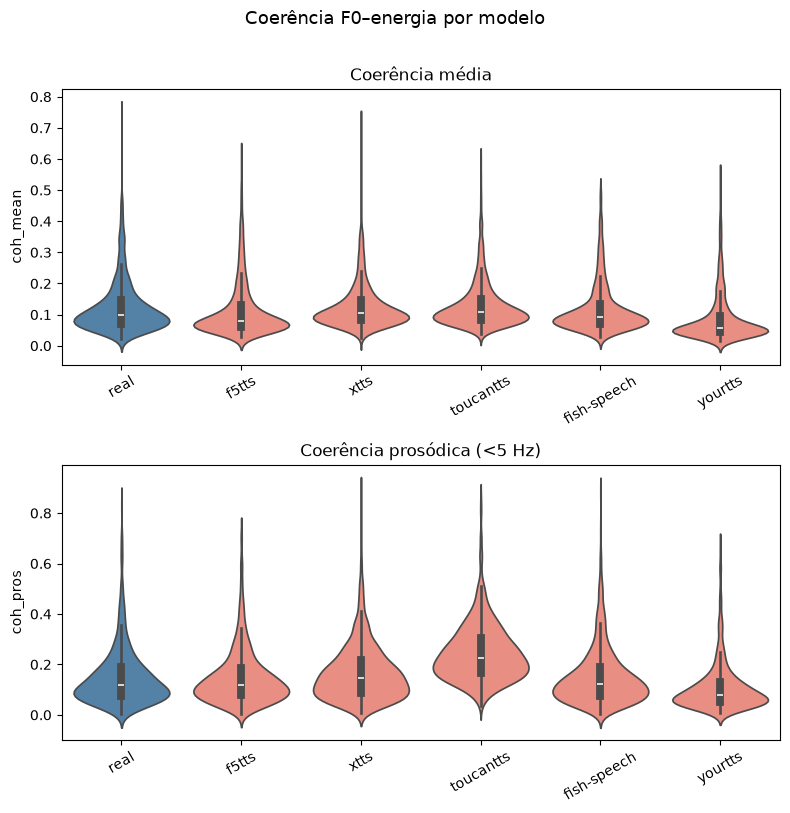

In [15]:
violin_por_modelo(PARAMS_COH, suptitle="Coerência F0–energia por modelo")


In [16]:
tabela_kl(PARAMS_COH)


,Coerência média,Coerência prosódica (<5 Hz)
Model,,
f5tts,0.0515,0.0079
xtts,0.0514,0.0315
toucantts,0.0718,0.6785
fish-speech,0.0229,0.0063
yourtts,0.2609,0.1420


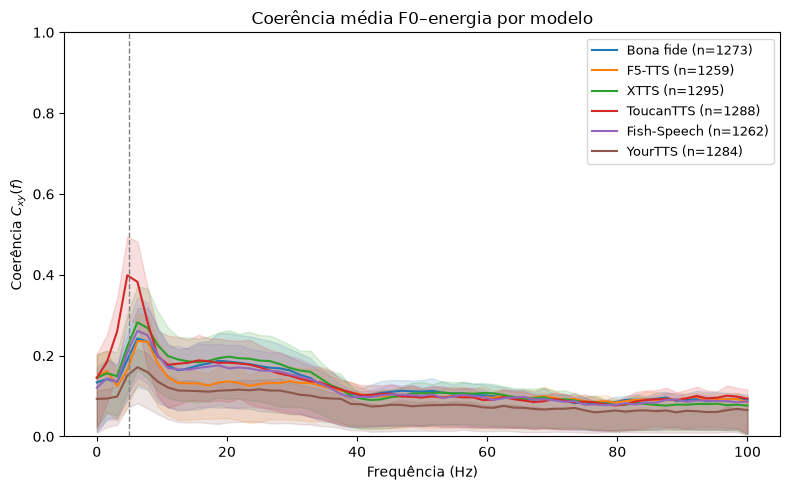

In [17]:
grupos_mod = {NOMES[m]: _matriz_curvas(data["modelo_grupo"] == m) for m in ORDEM}
curva_media(grupos_mod, suptitle="Coerência média F0–energia por modelo")


### Observações — Coerência F0–energia

**Cobertura.** 7.661/7.891 estimativas válidas (97,1%); 230 utterances descartadas por serem curtas demais para ≥3 segmentos de Welch. Grade de 65 bins (0–100 Hz, res. 1,56 Hz), com apenas **4 bins na banda < 5 Hz** — resolução baixa justamente onde o efeito é esperado (ver ressalvas).

**Resultado principal — a hipótese NÃO se confirmou (inverteu-se no agregado).**

- A hipótese previa coerência prosódica **maior no real**; o observado é o **oposto**: `coh_pros` mediana **real 0,119 vs falso 0,136** (médias 0,150 vs 0,165). O falso é igual ou ligeiramente **mais** coerente.
- `coh_mean` praticamente **não separa** (real 0,098 vs falso 0,091) — como a validação sintética antecipava, o ruído de alta frequência domina a média global. Confirma-se que `coh_mean` não serve como feature.
- **Magnitudes absolutas baixas** em ambos (~0,12–0,16 na banda prosódica): o acoplamento F0–energia medido é **fraco** em real *e* falso. O sinal de produção esperado não aparece como coerência alta na fala genuína desta base.
- **Leitura honesta:** o mecanismo fisiológico postulado (pressão subglótica acoplando altura e intensidade) não se traduz em maior coerência medida. Hipóteses: (a) TTS modernos geram contornos de F0/energia mais suaves e regularizados, o que *aumenta* a correlação artificialmente; (b) a fala real tem mais micro-variação independente entre F0 e energia; (c) confundidor de interpolação (ver ressalvas).

**Por modelo (KL) — onde a coerência de fato discrimina.**

| Modelo | KL `coh_mean` | KL `coh_pros` |
|---|---|---|
| F5-TTS | 0,0515 | 0,0079 |
| XTTS | 0,0514 | 0,0315 |
| ToucanTTS | 0,0718 | **0,6785** |
| Fish-Speech | 0,0229 | **0,0063** |
| YourTTS | 0,2609 | 0,1420 |

- A discriminação é **quase toda do ToucanTTS** (`coh_pros` KL = 0,68, uma ordem de grandeza acima dos demais) — único modelo cujo acoplamento F0–energia destoa fortemente do real.
- **F5-TTS, XTTS e Fish-Speech reproduzem o acoplamento quase perfeitamente** (KL < 0,04): para esses três a coerência não separa real de falso.
- **Fish-Speech** é de novo o mais próximo do real (KL 0,0063, o menor) — mais um eixo em que "cola" no genuíno.
- **YourTTS** destoa também na `coh_mean` (KL 0,26), mas na banda prosódica é só moderado (0,14).


# 3. (Opcional) Coerência F0–ZCR

Mesma receita aplicada ao par (F0, taxa de cruzamento por zero). Mais exploratória:
a relação fisiológica F0–ZCR é menos direta que F0–energia.


In [18]:
PARAMS_COH_ZCR = {"Coerência F0–ZCR (<5 Hz)": "coh_zcr_pros"}
resumo_real_falso(PARAMS_COH_ZCR)


,real,falso
Coerência F0–ZCR (<5 Hz),0.07394 (0.1063 ± 0.105),0.07877 (0.1109 ± 0.1037)


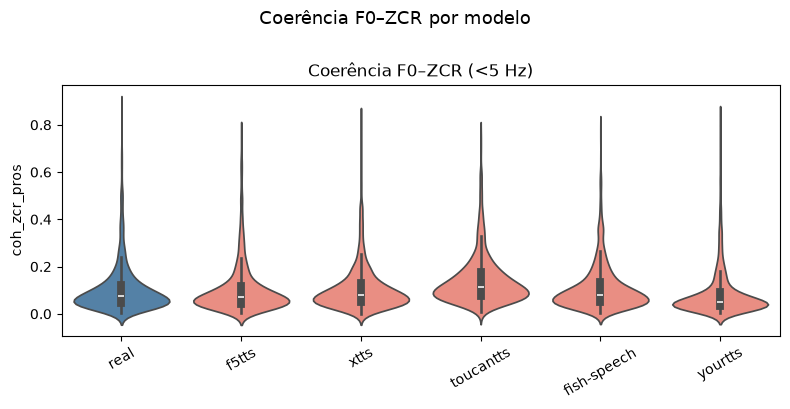

In [19]:
violin_por_modelo(PARAMS_COH_ZCR, suptitle="Coerência F0–ZCR por modelo")


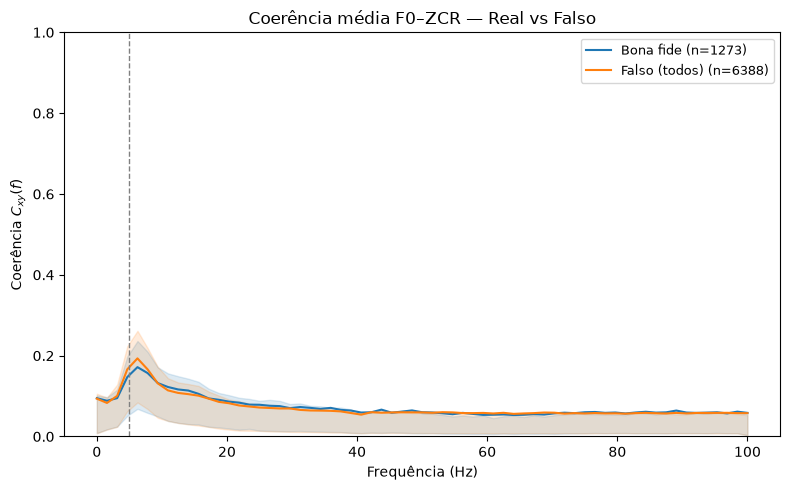

In [20]:
grupos_zcr = {
    NOMES["real"]:  _matriz_curvas(data["grupo"] == "real", col="coh_zcr_curve"),
    "Falso (todos)": _matriz_curvas(data["grupo"] == "falso", col="coh_zcr_curve"),
}
curva_media(grupos_zcr, suptitle="Coerência média F0–ZCR — Real vs Falso")


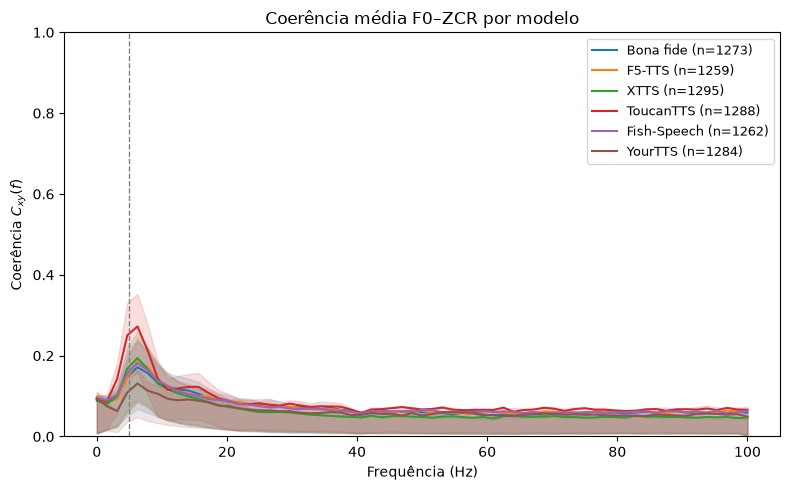

In [21]:
grupos_zcr_mod = {NOMES[m]: _matriz_curvas(data["modelo_grupo"] == m, col="coh_zcr_curve")
                  for m in ORDEM}
curva_media(grupos_zcr_mod, suptitle="Coerência média F0–ZCR por modelo")

### Observações — Coerência F0–ZCR

- **Não discrimina:** real 0,074 vs falso 0,079 — diferença mínima, com o falso de novo marginalmente acima. Confirma a expectativa de que o par F0–ZCR, sem vínculo fisiológico direto, é pouco informativo. Pode ficar de fora do texto final ou entrar apenas como **controle negativo**.


### Cruzamento com as análises anteriores e a tabela de qualidade

- **ToucanTTS é o outlier prosódico consistente em TODAS as análises:** F0-std (KL 1,95) + duração de pausa (KL 1,57) + agora coerência F0–energia (KL 0,68). Três medidas independentes de prosódia apontam o mesmo modelo, convergindo fortemente com seu **pior WER (19,18%)** — prosódia/ritmo quebrados que viram erro de pronúncia. Evidência robusta e replicada.
- **Fish-Speech é o mais fiel também aqui** (menor KL), reforçando o padrão das análises anteriores e sua **maior Spk. Sim. (0,76)**.
- **A coerência NÃO captura o YourTTS** como o pior (KL 0,14, moderado), ao contrário das métricas de ruído/HNR onde YourTTS era o mais distante. Ou seja, a coerência mede um **eixo diferente**: pega a quebra de *acoplamento prosódico* (ToucanTTS), não a degradação de *qualidade de sinal/ruído* (YourTTS).
- **Redundância (a pergunta da seção 4):** a coerência é **parcialmente redundante** com o KL de F0-std para detectar ToucanTTS (ambos sinalizam o mesmo modelo) e **fraca para os demais**. Como detector isolado agrega pouco; como *evidência convergente* de prosódia artificial do ToucanTTS, agrega bastante.


# 4. Síntese

- **A hipótese de produção falhou no sentido previsto:** não há coerência F0–energia *maior* na fala real; o falso é igual ou ligeiramente *mais* coerente. Vale reportar isso explicitamente como **resultado negativo** — é informativo por si só.
- **`coh_pros` só é discriminativo para o ToucanTTS.** Para F5-TTS/XTTS/Fish-Speech a feature não separa real de falso.
- **Como marcador de spoof, a coerência tem valor limitado e não-geral** — útil como peça de um conjunto (sobretudo confirmando ToucanTTS), não como feature stand-alone. **RMS das pausas e HNR continuam mais fortes e mais universais.**
- **Mensagem defensável:** TTS de ponta já reproduzem (ou excedem) o acoplamento prosódico F0–energia da fala humana, o que **enfraquece a premissa** de que esse vínculo de produção seja marcador confiável de autenticidade — exceto em modelos com prosódia visivelmente defeituosa (ToucanTTS).


# 5. Ressalvas metodológicas

- **Confundidor de interpolação (prioritário).** O F0 não-vozeado (−1) é interpolado, inserindo trechos de **reta determinísticos** que podem inflar a coerência artificialmente. Se a fração não-vozeada **diferir entre real e falso**, isso sozinho poderia explicar o sinal invertido (falso > real). **Checar a fração interpolada por grupo é o primeiro passo** antes de qualquer conclusão.
- **Resolução grosseira na banda de interesse.** Apenas **4 bins < 5 Hz** com `NPERSEG=128` — a média prosódica é estimada sobre pouquíssimos pontos, logo frágil. Vale repetir com `NPERSEG=256` (7 bins < 5 Hz) e ver se a inversão persiste, ainda que custe mais descartes.
- **Viés do Welch.** Coerência de poucos segmentos é enviesada para cima; com `MIN_SEG=3` as utterances no limite podem ter coerência inflada. Conferir se o viés afeta um grupo mais que o outro (distribuição de comprimentos por grupo).
- **Coerência absoluta baixa (~0,1)** em ambos os grupos reduz a margem para qualquer separação confiável.
- **`coh_mean` (todas as frequências) é fraco** — dilui o sinal com bins de alta frequência ruidosos; usar apenas como contexto e reportar `coh_pros`.
- **KL é direcional e sensível à binagem/KDE** — ranking relativo, não valor absoluto. Para `coh_pros`, reportar **a direção** (falso acima ou abaixo do real por modelo), já que o agregado sugere "falso acima".
- **Desbalanceamento 83/17** e **split por locutor** permanecem válidos para qualquer uso classificatório (F1/AUC, reponderação).
